In [38]:
import numpy as np
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.datasets import make_blobs
from itertools import combinations
from scipy.spatial.distance import cdist
from scipy.stats import norm
import sys
sys.path.insert(1, './utils/')
from ANALYSISutils import *

In [4]:
def compute_fid(X_1, X_2, eps=1e-6):
    """
    Compute the Fréchet Inception Distance (FID) between two sets of samples.
    
    Parameters:
        X_1: np.ndarray, shape (n_samples_1, n_features)
        X_2: np.ndarray, shape (n_samples_2, n_features)
        eps: small value for numerical stability in covariance
    
    Returns:
        fid: float, the FID score
    """
    # Compute means
    mu_1 = np.mean(X_1, axis=0)
    mu_2 = np.mean(X_2, axis=0)
    
    # Compute covariances
    sigma_1 = np.cov(X_1, rowvar=False) + eps * np.eye(X_1.shape[1])
    sigma_2 = np.cov(X_2, rowvar=False) + eps * np.eye(X_2.shape[1])

    # Compute sqrt of product of covariances
    covmean = sqrtm(sigma_1 @ sigma_2)

    # Handle numerical issues
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # Compute the FID
    mean_diff = np.sum((mu_1 - mu_2) ** 2)
    trace_term = np.trace(sigma_1 + sigma_2 - 2 * covmean)

    fid = mean_diff + trace_term
    return fid


# example

In [3]:
# Two samples in feature space (e.g., Inception-v3 pool3 output)
X_1 = np.random.randn(1000, 2048)  # real images
X_2 = np.random.randn(1000, 2048) + 0.1  # generated images

fid_score = compute_fid(X_1, X_2)
print(f"FID: {fid_score:.4f}")

FID: 1820.1481


# histology

In [34]:
! mkdir ./output/histology/FID

In [42]:
#load training data
files = np.load('./data/liver_train.npz')
ref_all_x, ref_all_y = files['data'], files['labels']
print(ref_all_x.shape)

#load test data
files = np.load('./data/liver_test_and_anomaly.npz')
data_all_x, data_all_y = files['data'], files['labels']
anomalous_class=8
Pois_ON=False

sig_all_x = data_all_x[data_all_y==anomalous_class]
sig_all_y = data_all_y[data_all_y==anomalous_class]
bkg_all_x = data_all_x[data_all_y!=anomalous_class]
bkg_all_y = data_all_y[data_all_y!=anomalous_class]
print(sig_all_x.shape, bkg_all_x.shape )

(6296, 4)
(893, 4) (655, 4)


In [44]:
#calibration
N_Sig = 0
N_Bkg = 500-N_Sig

t0 = []
for toy in range(500):
    N_bkg_p, N_sig_p = N_Bkg, N_Sig
    if Pois_ON:
        N_bkg_p = np.random.poisson(lam=N_Bkg, size=1)[0]
        N_sig_p = np.random.poisson(lam=N_Sig, size=1)[0]
    
    idx_bkg = np.arange(bkg_all_y.shape[0])
    np.random.shuffle(idx_bkg)
    idx_sig = np.arange(sig_all_y.shape[0])
    np.random.shuffle(idx_sig)
    
    X_test = np.concatenate((sig_all_x[idx_sig[:N_sig_p]], bkg_all_x[idx_bkg[:N_bkg_p]], ref_all_x), axis=0)
    Y_test = np.concatenate((np.ones((N_sig_p+N_bkg_p, )), np.zeros((len(ref_all_x),))), axis=0)
    test_toy = compute_fid(X_test[Y_test==1], X_test[Y_test==0] )
    if not toy: print(test_toy)
    t0.append(test_toy)
t0=np.array(t0)
np.save('./output/histology/FID/NB500_NS0.npy', t0)

4.513948766929985


In [45]:
t1_dict = {}
#test
for N_Sig in [10, 25, 50, 100]:
    N_Bkg = 500-N_Sig
    
    t1_dict['NS=%i'%(N_Sig)] = []
    for toy in range(500):
        N_bkg_p, N_sig_p = N_Bkg, N_Sig
        if Pois_ON:
            N_bkg_p = np.random.poisson(lam=N_Bkg, size=1)[0]
            N_sig_p = np.random.poisson(lam=N_Sig, size=1)[0]
        
        idx_bkg = np.arange(bkg_all_y.shape[0])
        np.random.shuffle(idx_bkg)
        idx_sig = np.arange(sig_all_y.shape[0])
        np.random.shuffle(idx_sig)
        
        X_test = np.concatenate((sig_all_x[idx_sig[:N_sig_p]], bkg_all_x[idx_bkg[:N_bkg_p]], ref_all_x), axis=0)
        Y_test = np.concatenate((np.ones((N_sig_p+N_bkg_p, )), np.zeros((len(ref_all_x),))), axis=0)
        test_toy = compute_fid(X_test[Y_test==1], X_test[Y_test==0] )
        if not toy: print(test_toy)
        t1_dict['NS=%i'%(N_Sig)].append(test_toy)
    t1_dict['NS=%i'%(N_Sig)]=np.array(t1_dict['NS=%i'%(N_Sig)])
    np.save('./output/histology/FID/NB500_NS%i.npy'%(N_Sig), t1_dict['NS=%i'%(N_Sig)])

5.956413522018067
13.528005653333082
51.78897381292032
199.20748099323797


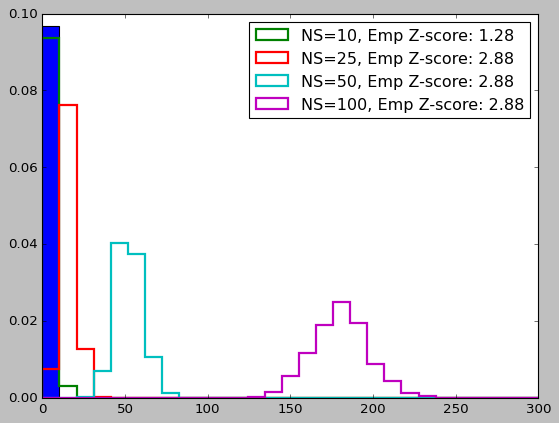

In [48]:
h = plt.hist(t0, bins=np.linspace(0, 300, 30), density=True)
for k in list(t1_dict.keys()):
    t1=t1_dict[k]
    pval=(1+np.sum(t0>np.median(t1)))/(1+len(t0))
    Zscore = norm.ppf(1-pval)
    plt.hist(t1, bins=h[1], density=True, histtype='step', lw=2, label=k+', Emp Z-score: '+str(np.around(Zscore, 2)))
plt.legend()
plt.savefig('./output/histology/FID/summary_plot.pdf')
plt.show()

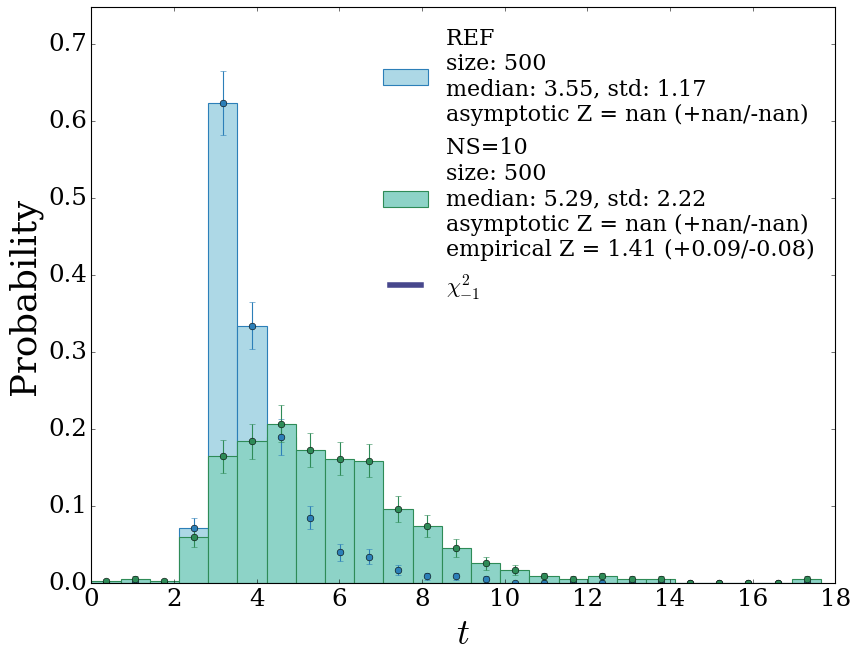

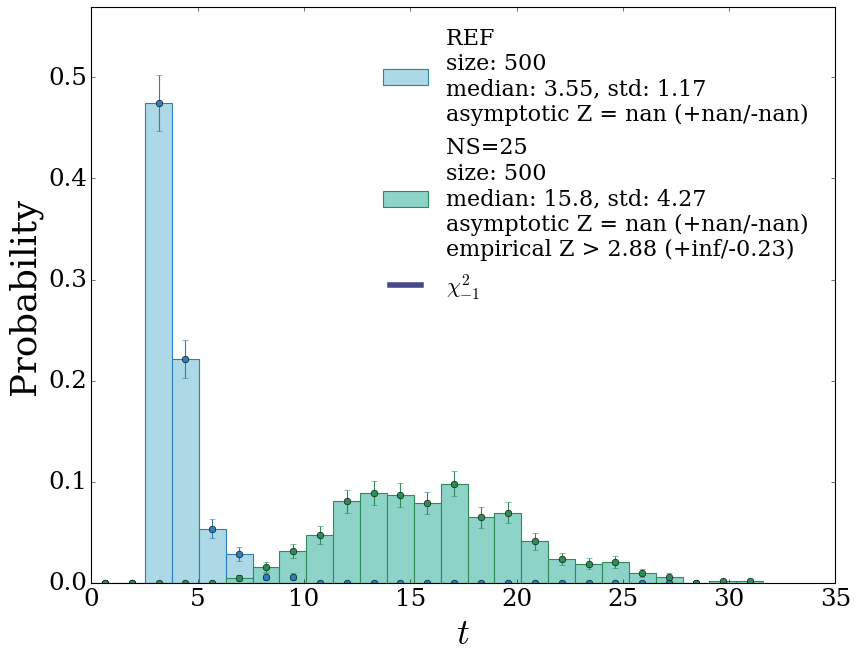

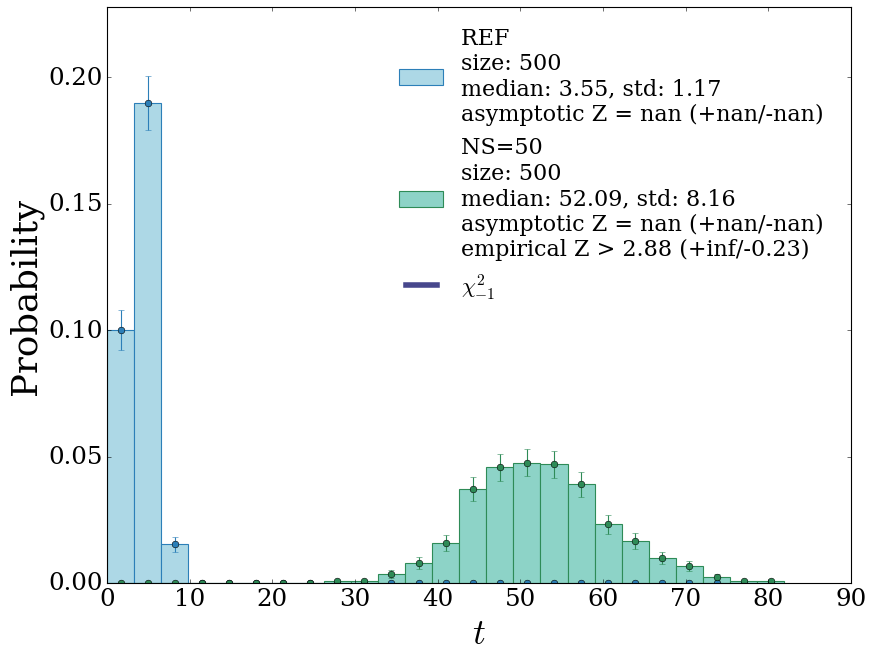

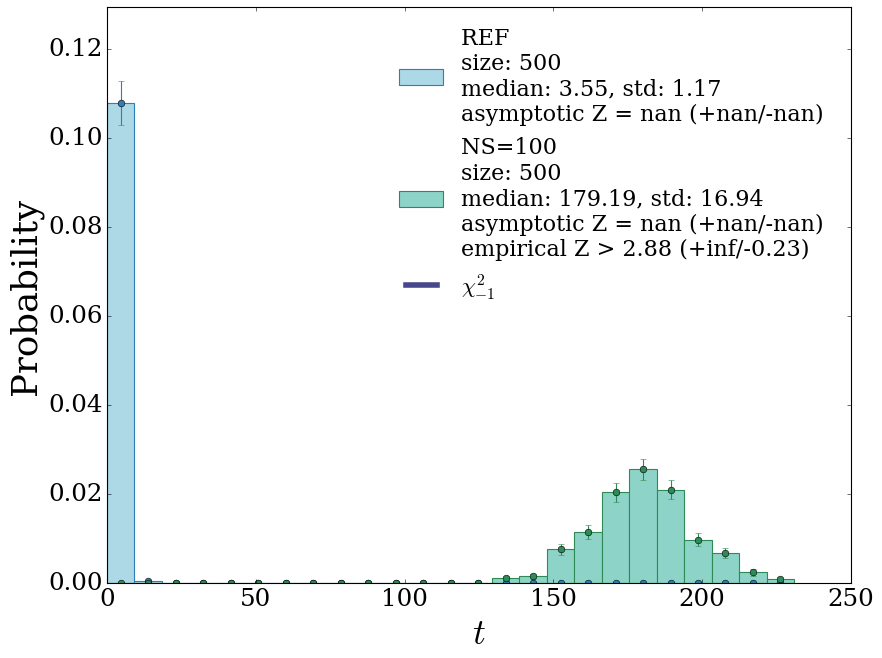

In [50]:
for k in list(t1_dict.keys()):
    t2=t1_dict[k]
    t1=t0
    z_as, z_emp = plot_2distribution(t1, t2, df=-1, xmin=0, xmax=np.max(t2), #ymax=0.03, 
                               nbins=25, save=True, output_path='./output/histology/FID/',
                               label1='REF', label2=k, save_name=k, print_Zscore=True)

# GW

In [28]:
! mkdir ./output/GWAK/FID

In [29]:
#load training data
files = np.load('./data/GWAK_test_and_anomaly.npz')
ref_all_x, ref_all_y = files['data'], files['labels']
ref_all_x = ref_all_x[ref_all_y!=anomalous_class]
print(ref_all_x.shape)

#load test data
files = np.load('./data/GWAK_test_and_anomaly.npz')
data_all_x, data_all_y = files['data'], files['labels']
anomalous_class=8
Pois_ON=False

sig_all_x = data_all_x[data_all_y==anomalous_class]
sig_all_y = data_all_y[data_all_y==anomalous_class]
bkg_all_x = data_all_x[data_all_y!=anomalous_class]
bkg_all_y = data_all_y[data_all_y!=anomalous_class]
print(sig_all_x.shape, bkg_all_x.shape )

(49781, 4)
(32000, 4) (49781, 4)


In [30]:
#calibration
N_Bkg = 4000
N_ref = 20000

t0 = []
for toy in range(500):
    N_bkg_p = N_Bkg
    if Pois_ON:
        N_bkg_p = np.random.poisson(lam=N_Bkg, size=1)[0]
    
    idx_bkg = np.arange(bkg_all_y.shape[0])
    np.random.shuffle(idx_bkg)
    
    X_test = ref_all_x[idx_bkg[:N_ref+N_bkg_p]]
    Y_test = np.concatenate((np.ones((N_bkg_p, )), np.zeros((N_ref,))), axis=0)
    test_toy = compute_fid(X_test[Y_test==1], X_test[Y_test==0] )
    if not toy: print(test_toy)
    t0.append(test_toy)
t0=np.array(t0)
np.save('./output/GWAK/FID/NB%i_NS0.npy'%(N_Bkg), t0)

0.32192194832565235


In [31]:
t1_dict = {}
N_Bkg = 4000
N_ref = 20000
#test
for N_Sig in [20, 40, 100, 160, 200]: 
    print('N(S)=', N_Sig)
    t1_dict['NS=%i'%(N_Sig)] = []
    for toy in range(500):
        N_bkg_p, N_sig_p = N_Bkg, N_Sig
        if Pois_ON:
            N_bkg_p = np.random.poisson(lam=N_Bkg, size=1)[0]
            N_sig_p = np.random.poisson(lam=N_Sig, size=1)[0]
        
        idx_bkg = np.arange(bkg_all_y.shape[0])
        np.random.shuffle(idx_bkg)
        idx_sig = np.arange(sig_all_y.shape[0])
        np.random.shuffle(idx_sig)
        
        X_test = np.concatenate((sig_all_x[idx_sig[:N_sig_p]], bkg_all_x[idx_bkg[:N_bkg_p+N_ref]]), axis=0)
        Y_test = np.concatenate((np.ones((N_sig_p+N_bkg_p, )), np.zeros((N_ref, ))), axis=0)
        test_toy = compute_fid(X_test[Y_test==1], X_test[Y_test==0] )
        if not toy%100: print(toy, test_toy)
        t1_dict['NS=%i'%(N_Sig)].append(test_toy)
    t1_dict['NS=%i'%(N_Sig)]=np.array(t1_dict['NS=%i'%(N_Sig)])
    np.save('./output/GWAK/FID/NB%i_NS%i.npy'%(N_Bkg, N_Sig), t1_dict['NS=%i'%(N_Sig)])

N(S)= 20
0 0.18442420966701434
100 0.07336337924240866
200 0.17393894732661863
300 0.09697574628465588
400 0.15882840908015794
N(S)= 40
0 0.0861284179925974
100 0.11227428591779187
200 0.12160892530206979
300 0.16358009873533774
400 0.036254417283089424
N(S)= 100
0 0.4052755301056834
100 0.1282684217686949
200 0.356446436997615
300 0.1712125691717148
400 0.10839617281871483
N(S)= 160
0 0.701569329241309
100 0.5269659272527321
200 0.3406419314740532
300 0.2048385891575606
400 0.37190225428594204
N(S)= 200
0 0.24348064770977373
100 0.3913462277621278
200 0.3139408272713382
300 0.5749875865130889
400 0.14149578369990934


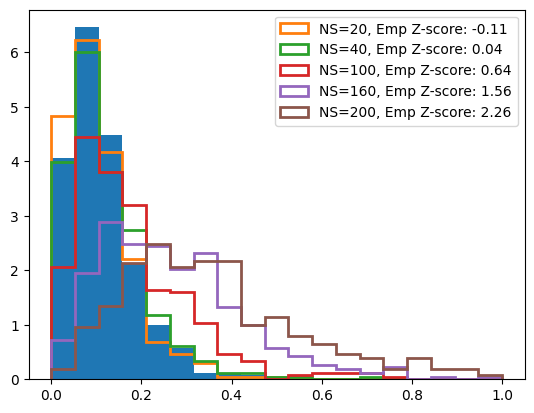

In [33]:
h = plt.hist(t0, bins=np.linspace(0, 1, 20), density=True)
for k in list(t1_dict.keys()):
    t1=t1_dict[k]
    pval=(1+np.sum(t0>np.median(t1)))/(1+len(t0))
    Zscore = norm.ppf(1-pval)
    plt.hist(t1, bins=h[1], density=True, histtype='step', lw=2, label=k+', Emp Z-score: '+str(np.around(Zscore, 2)))
plt.legend()
plt.savefig('./output/GWAK/FID/summary_plot.pdf')
plt.show()

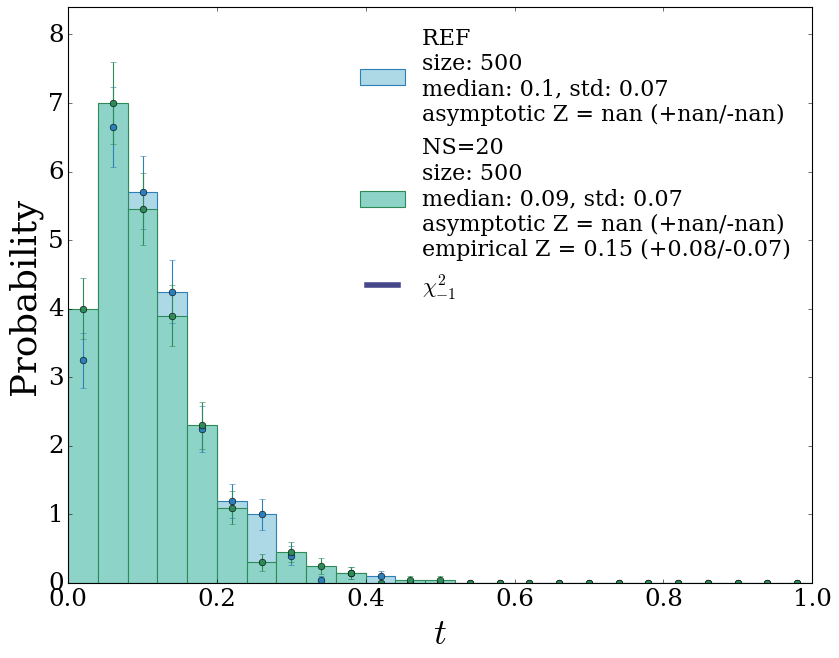

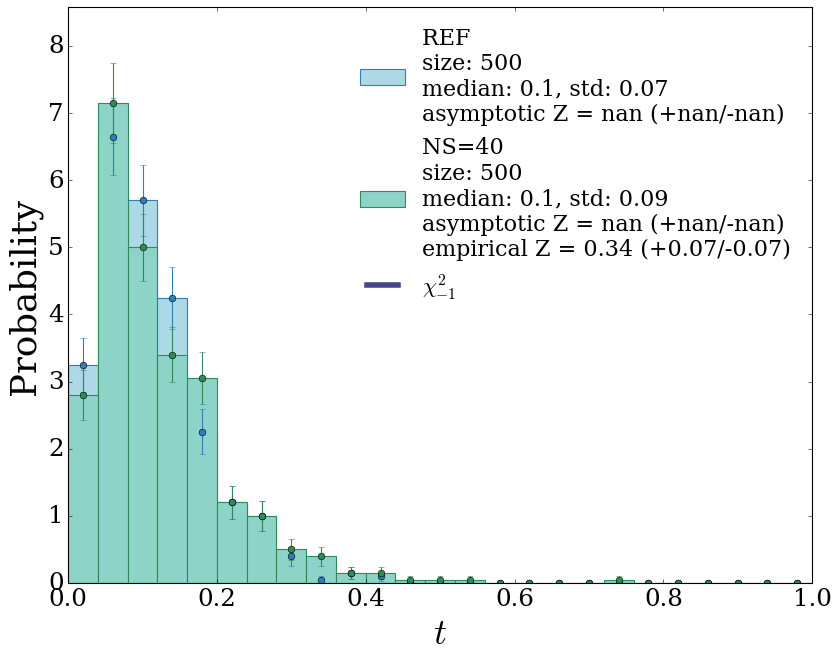

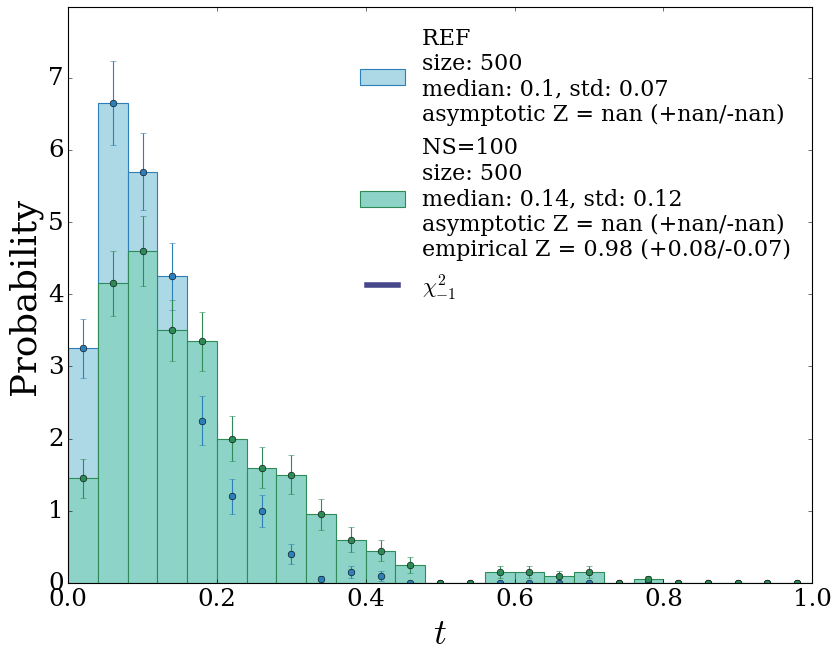

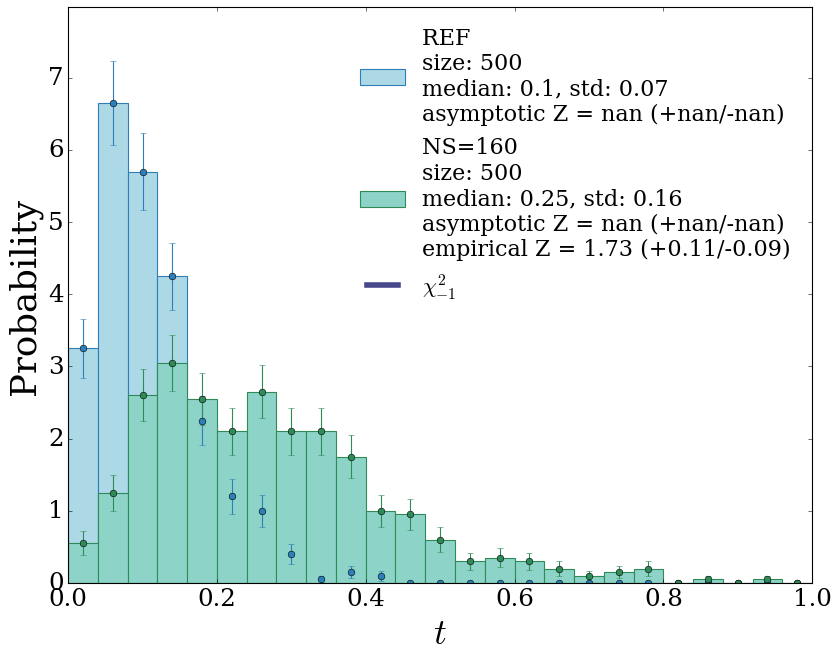

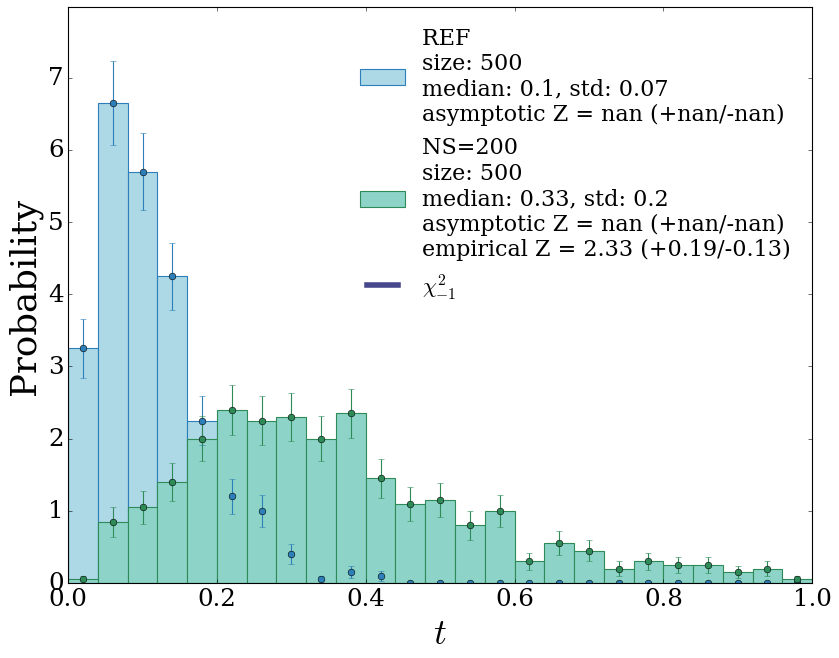

In [41]:
for k in list(t1_dict.keys()):
    t2=t1_dict[k]
    t1=t0
    z_as, z_emp = plot_2distribution(t1, t2, df=-1, xmin=0, xmax=1, #ymax=0.03, 
                               nbins=25, save=True, output_path='./output/GWAK/FID/',
                               label1='REF', label2=k, save_name=k, print_Zscore=True)